In [1]:
# ============================================================
# VOLTRELAY ENERGY
# DATA ANALYTICS HACKATHON
# FINAL ROBUST COLAB NOTEBOOK
# ============================================================

import os
import re
import csv
import gc
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

DATA_PATH = "/content"

print("✅ Libraries loaded")

✅ Libraries loaded


In [2]:
# ============================================================
# 2. HELPER FUNCTIONS
# ============================================================

def clean_columns(df):

    df = df.copy()

    cols = []

    for c in df.columns:

        c = str(c).strip().lower()

        c = re.sub(
            r"[^a-z0-9_]+",
            "_",
            c
        )

        c = re.sub(
            r"_+",
            "_",
            c
        ).strip("_")

        cols.append(c)

    # Make duplicate column names unique
    seen = {}

    final_cols = []

    for c in cols:

        if c not in seen:

            seen[c] = 0
            final_cols.append(c)

        else:

            seen[c] += 1
            final_cols.append(
                f"{c}_{seen[c]}"
            )

    df.columns = final_cols

    return df


def load_csv(filename):

    path = os.path.join(
        DATA_PATH,
        filename
    )

    print(f"Loading {filename} ...")

    try:

        df = pd.read_csv(
            path,
            low_memory=False,
            on_bad_lines="skip"
        )

    except TypeError:

        df = pd.read_csv(
            path,
            low_memory=False
        )

    df = clean_columns(df)

    print(
        f"✅ {filename}: "
        f"{len(df):,} rows × "
        f"{len(df.columns)} columns"
    )

    return df


def numeric(df, col):

    if col in df.columns:

        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

    return df


def datetime_col(df, col):

    if col in df.columns:

        df[col] = pd.to_datetime(
            df[col],
            errors="coerce"
        )

    return df


def show_if_exists(df, columns):

    cols = [
        c for c in columns
        if c in df.columns
    ]

    if cols:

        display(
            df[cols].head()
        )

    else:

        print("No requested columns available.")

In [3]:
# ============================================================
# 3. LOAD SMALL DATASETS
# ============================================================

riders = load_csv(
    "riders.csv"
)

batteries = load_csv(
    "batteries.csv"
)

stations = load_csv(
    "stations.csv"
)

support_tickets = load_csv(
    "support_tickets.csv"
)

city_daily_context = load_csv(
    "city_daily_context.csv"
)

fleet_partners = load_csv(
    "fleet_partners.csv"
)

Loading riders.csv ...
✅ riders.csv: 20,000 rows × 12 columns
Loading batteries.csv ...
✅ batteries.csv: 6,500 rows × 13 columns
Loading stations.csv ...
✅ stations.csv: 152 rows × 22 columns
Loading support_tickets.csv ...
✅ support_tickets.csv: 44,000 rows × 12 columns
Loading city_daily_context.csv ...
✅ city_daily_context.csv: 3,282 rows × 12 columns
Loading fleet_partners.csv ...
✅ fleet_partners.csv: 12 rows × 12 columns


In [4]:
# ============================================================
# 4. LOAD SWAP EVENTS
# ============================================================

DATA_PATH = "/content"
swap_path = os.path.join(DATA_PATH, "swap_events.csv")
print("📁 DATA_PATH:", DATA_PATH)
print("📄 swap_path:", swap_path)

print("=" * 70)
print("LOADING SWAP EVENTS")
print("=" * 70)

# First inspect header only
with open(
    swap_path,
    "r",
    encoding="utf-8-sig",
    errors="replace",
    newline=""
) as f:

    reader = csv.reader(
        f,
        delimiter=",",
        quotechar='"'
    )

    header = next(reader)

print(
    "Detected columns:",
    len(header)
)

print(
    header
)

📁 DATA_PATH: /content
📄 swap_path: /content/swap_events.csv
LOADING SWAP EVENTS
Detected columns: 22
['event_id', 'rider_id', 'station_id', 'event_ts', 'event_type', 'attempt_seq', 'queue_wait_sec', 'battery_in_id', 'battery_out_id', 'soc_in_pct', 'soh_in_pct', 'soc_out_pct', 'soh_out_pct', 'km_since_last_swap', 'tariff_code', 'list_price_inr', 'discount_inr', 'amount_charged_inr', 'payment_mode', 'energy_to_recharge_kwh', 'station_firmware', 'sync_mode']


In [5]:
DATA_PATH = "/content"
swap_path = os.path.join(DATA_PATH, "swap_events.csv")

# ============================================================
# 5. LOAD SWAP CSV
# ============================================================

# Explicit parser settings.
# No automatic dialect sniffing.

swap_events = pd.read_csv(
    swap_path,
    sep=",",
    quotechar='"',
    escapechar="\\",
    encoding="utf-8-sig",
    low_memory=False,
    on_bad_lines="skip"
)

swap_events = clean_columns(
    swap_events
)

print(
    f"✅ swap_events loaded: "
    f"{len(swap_events):,} rows × "
    f"{len(swap_events.columns)} columns"
)

print(
    "\nColumns:"
)

print(
    swap_events.columns.tolist()
)

✅ swap_events loaded: 150,658 rows × 22 columns

Columns:
['event_id', 'rider_id', 'station_id', 'event_ts', 'event_type', 'attempt_seq', 'queue_wait_sec', 'battery_in_id', 'battery_out_id', 'soc_in_pct', 'soh_in_pct', 'soc_out_pct', 'soh_out_pct', 'km_since_last_swap', 'tariff_code', 'list_price_inr', 'discount_inr', 'amount_charged_inr', 'payment_mode', 'energy_to_recharge_kwh', 'station_firmware', 'sync_mode']


In [6]:
# ============================================================
# 7. VALID EVENT TYPES
# ============================================================

VALID_EVENTS = {
    "swap_completed",
    "failed_no_charged_battery",
    "abandoned_queue",
    "cancelled_by_rider",
    "failed_system_error"
}

if "event_type" in swap_events.columns:

    before = len(
        swap_events
    )

    swap_events[
        "event_type"
    ] = (
        swap_events[
            "event_type"
        ]
        .astype("string")
        .str.strip()
        .str.lower()
    )

    swap_events = swap_events[
        swap_events[
            "event_type"
        ].isin(
            VALID_EVENTS
        )
    ].copy()

    after = len(
        swap_events
    )

    print(
        f"Rows before event cleaning : {before:,}"
    )

    print(
        f"Rows after event cleaning  : {after:,}"
    )

    print(
        f"Malformed/unknown rows removed: "
        f"{before-after:,}"
    )

    print("\nEvent types:")
    display(
        swap_events[
            "event_type"
        ]
        .value_counts()
        .to_frame(
            "count"
        )
    )# ============================================================
# 7. VALID EVENT TYPES
# ============================================================

VALID_EVENTS = {
    "swap_completed",
    "failed_no_charged_battery",
    "abandoned_queue",
    "cancelled_by_rider",
    "failed_system_error"
}

if "event_type" in swap_events.columns:

    before = len(
        swap_events
    )

    swap_events[
        "event_type"
    ] = (
        swap_events[
            "event_type"
        ]
        .astype("string")
        .str.strip()
        .str.lower()
    )

    swap_events = swap_events[
        swap_events[
            "event_type"
        ].isin(
            VALID_EVENTS
        )
    ].copy()

    after = len(
        swap_events
    )

    print(
        f"Rows before event cleaning : {before:,}"
    )

    print(
        f"Rows after event cleaning  : {after:,}"
    )

    print(
        f"Malformed/unknown rows removed: "
        f"{before-after:,}"
    )

    print("\nEvent types:")
    display(
        swap_events[
            "event_type"
        ]
        .value_counts()
        .to_frame(
            "count"
        )
    )

Rows before event cleaning : 150,658
Rows after event cleaning  : 150,657
Malformed/unknown rows removed: 1

Event types:


,count
event_type,
swap_completed,144005
failed_no_charged_battery,3670
abandoned_queue,1920
cancelled_by_rider,616
failed_system_error,446


Rows before event cleaning : 150,657
Rows after event cleaning  : 150,657
Malformed/unknown rows removed: 0

Event types:


,count
event_type,
swap_completed,144005
failed_no_charged_battery,3670
abandoned_queue,1920
cancelled_by_rider,616
failed_system_error,446


In [7]:
# ============================================================
# 8. DATA QUALITY
# ============================================================

quality = pd.DataFrame({
    "column": swap_events.columns,
    "missing": [
        swap_events[c].isna().sum()
        for c in swap_events.columns
    ]
})

quality[
    "missing_pct"
] = (
    quality["missing"]
    /
    len(swap_events)
    * 100
)

quality = quality.sort_values(
    "missing_pct",
    ascending=False
)

display(
    quality
)

,column,missing,missing_pct
11,soc_out_pct,6652,4.415328
8,battery_out_id,6652,4.415328
19,energy_to_recharge_kwh,6652,4.415328
12,soh_out_pct,6652,4.415328
9,soc_in_pct,1062,0.704912
10,soh_in_pct,1062,0.704912
13,km_since_last_swap,1062,0.704912
7,battery_in_id,1062,0.704912
5,attempt_seq,0,0.000000
4,event_type,0,0.000000


In [8]:
# ============================================================
# 9. QUESTION 1 — BASIC NETWORK KPIs
# ============================================================

print("=" * 70)
print("QUESTION 1 — NETWORK PERFORMANCE")
print("=" * 70)

# Total attempts
total_attempts = len(swap_events)

# Completed swaps
if "event_type" in swap_events.columns:

    completed_mask = (
        swap_events["event_type"]
        .astype("string")
        .str.strip()
        .str.lower()
        == "swap_completed"
    )

else:

    completed_mask = pd.Series(
        False,
        index=swap_events.index
    )

completed_swaps = int(
    completed_mask.sum()
)

# Completion rate
if total_attempts > 0:

    completion_rate = (
        completed_swaps
        / total_attempts
        * 100
    )

else:

    completion_rate = 0


# Failure / non-completion rate
failure_rate = (
    100
    - completion_rate
)


# Revenue
if "amount_charged_inr" in swap_events.columns:

    amount = pd.to_numeric(
        swap_events[
            "amount_charged_inr"
        ],
        errors="coerce"
    )

    revenue = amount[
        completed_mask
    ].sum()

else:

    revenue = np.nan


# Final KPI table
network_kpis = pd.DataFrame({
    "Metric": [
        "Total Swap Attempts",
        "Completed Swaps",
        "Completion Rate (%)",
        "Failure / Non-completion Rate (%)",
        "Revenue (INR)"
    ],

    "Value": [
        total_attempts,
        completed_swaps,
        round(
            completion_rate,
            2
        ),
        round(
            failure_rate,
            2
        ),
        round(
            revenue,
            2
        )
        if pd.notna(revenue)
        else "Not Available"
    ]
})


display(
    network_kpis
)


print("\n✅ Basic KPI analysis completed successfully.")

QUESTION 1 — NETWORK PERFORMANCE


,Metric,Value
0,Total Swap Attempts,150657.00
1,Completed Swaps,144005.00
2,Completion Rate (%),95.58
3,Failure / Non-completion Rate (%),4.42
4,Revenue (INR),8627651.40



✅ Basic KPI analysis completed successfully.


In [9]:
# ============================================================
# 10. MONTHLY NETWORK PERFORMANCE — FIXED
# ============================================================

print("=" * 70)
print("MONTHLY NETWORK PERFORMANCE")
print("=" * 70)

# Make a separate copy
temp = swap_events.copy()

# ------------------------------------------------------------
# STEP 1: Convert event_ts safely to datetime
# ------------------------------------------------------------

if "event_ts" not in temp.columns:

    print("❌ event_ts column not found.")

else:

    temp["event_ts"] = pd.to_datetime(
        temp["event_ts"],
        errors="coerce"
    )

    # Count valid / invalid dates
    valid_dates = temp["event_ts"].notna().sum()
    invalid_dates = temp["event_ts"].isna().sum()

    print(
        f"Valid timestamps   : {valid_dates:,}"
    )

    print(
        f"Invalid timestamps : {invalid_dates:,}"
    )

    # --------------------------------------------------------
    # STEP 2: Remove rows where date is invalid
    # --------------------------------------------------------

    temp = temp[
        temp["event_ts"].notna()
    ].copy()

    # --------------------------------------------------------
    # STEP 3: Create month
    # --------------------------------------------------------

    temp["month"] = (
        temp["event_ts"]
        .dt.to_period("M")
        .dt.to_timestamp()
    )

    # --------------------------------------------------------
    # STEP 4: Total attempts + completed swaps
    # --------------------------------------------------------

    monthly = (
        temp
        .groupby("month")
        .agg(
            total_attempts=(
                "event_type",
                "count"
            ),

            completed_swaps=(
                "event_type",
                lambda x:
                (
                    x.astype("string")
                    .str.strip()
                    .str.lower()
                    == "swap_completed"
                ).sum()
            )
        )
        .reset_index()
    )

    # --------------------------------------------------------
    # STEP 5: Completion rate
    # --------------------------------------------------------

    monthly["completion_rate_pct"] = np.where(
        monthly["total_attempts"] > 0,

        monthly["completed_swaps"]
        /
        monthly["total_attempts"]
        * 100,

        0
    )

    # --------------------------------------------------------
    # STEP 6: Failure rate
    # --------------------------------------------------------

    monthly["failure_rate_pct"] = (
        100
        -
        monthly["completion_rate_pct"]
    )

    # --------------------------------------------------------
    # STEP 7: Revenue
    # --------------------------------------------------------

    if "amount_charged_inr" in temp.columns:

        temp["amount_charged_inr"] = pd.to_numeric(
            temp["amount_charged_inr"],
            errors="coerce"
        )

        monthly_revenue = (
            temp[
                temp["event_type"]
                .astype("string")
                .str.strip()
                .str.lower()
                == "swap_completed"
            ]
            .groupby("month")[
                "amount_charged_inr"
            ]
            .sum()
            .reset_index(
                name="revenue_inr"
            )
        )

        monthly = monthly.merge(
            monthly_revenue,
            on="month",
            how="left"
        )

    # --------------------------------------------------------
    # STEP 8: Display
    # --------------------------------------------------------

    print("\n✅ Monthly analysis completed.")

    display(
        monthly
    )

MONTHLY NETWORK PERFORMANCE
Valid timestamps   : 150,657
Invalid timestamps : 0

✅ Monthly analysis completed.


,month,total_attempts,completed_swaps,completion_rate_pct,failure_rate_pct,revenue_inr
0,2024-01-01,110348,105490,95.597564,4.402436,6318995.2
1,2024-02-01,40309,38515,95.549381,4.450619,2308656.2


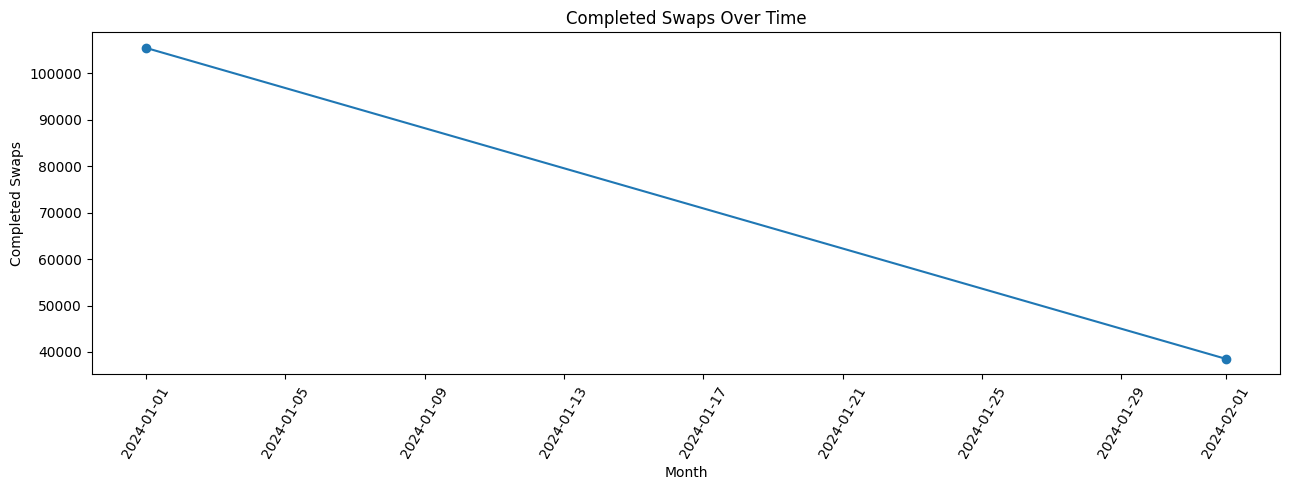

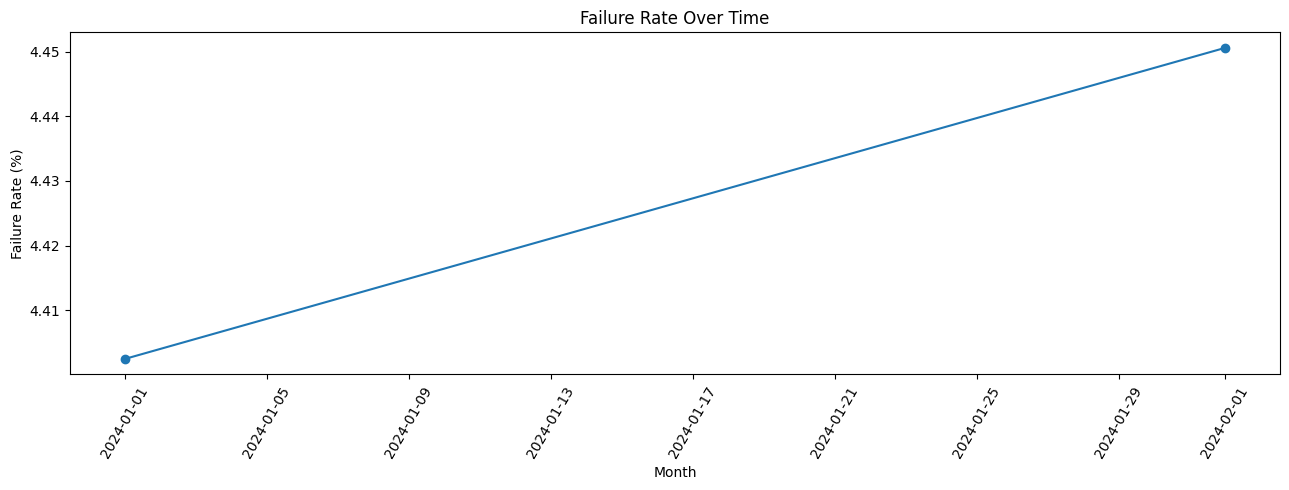

In [10]:
# ============================================================
# 11. MONTHLY CHART
# ============================================================

if len(monthly) > 0:

    plt.figure(
        figsize=(13, 5)
    )

    plt.plot(
        monthly["month"],
        monthly["completed_swaps"],
        marker="o"
    )

    plt.title(
        "Completed Swaps Over Time"
    )

    plt.xlabel(
        "Month"
    )

    plt.ylabel(
        "Completed Swaps"
    )

    plt.xticks(
        rotation=60
    )

    plt.tight_layout()

    plt.show()


if len(monthly) > 0:

    plt.figure(
        figsize=(13, 5)
    )

    plt.plot(
        monthly["month"],
        monthly["failure_rate_pct"],
        marker="o"
    )

    plt.title(
        "Failure Rate Over Time"
    )

    plt.xlabel(
        "Month"
    )

    plt.ylabel(
        "Failure Rate (%)"
    )

    plt.xticks(
        rotation=60
    )

    plt.tight_layout()

    plt.show()

In [11]:
# ============================================================
# 12. STATION PERFORMANCE
# ============================================================

print("=" * 70)
print("STATION PERFORMANCE")
print("=" * 70)

station_temp = swap_events.copy()

station_temp["event_type_clean"] = (
    station_temp["event_type"]
    .astype("string")
    .str.strip()
    .str.lower()
)

station_temp["station_id"] = (
    station_temp["station_id"]
    .astype("string")
    .str.strip()
)

station_performance = (
    station_temp
    .groupby("station_id")
    .agg(
        total_attempts=("event_type_clean", "count"),
        completed_swaps=(
            "event_type_clean",
            lambda x: (x == "swap_completed").sum()
        ),
        failed_attempts=(
            "event_type_clean",
            lambda x: (x != "swap_completed").sum()
        )
    )
    .reset_index()
)

station_performance["completion_rate_pct"] = np.where(
    station_performance["total_attempts"] > 0,
    station_performance["completed_swaps"]
    / station_performance["total_attempts"] * 100,
    0
)

station_performance["failure_rate_pct"] = (
    100 - station_performance["completion_rate_pct"]
)

station_performance = station_performance.sort_values(
    "total_attempts",
    ascending=False
)

print("\nTop stations by total attempts:")
display(station_performance.head(10))

STATION PERFORMANCE

Top stations by total attempts:


,station_id,total_attempts,completed_swaps,failed_attempts,completion_rate_pct,failure_rate_pct
18,STN-BLR-019,2482,2364,118,95.245770,4.754230
30,STN-DEL-043,2343,2233,110,95.305164,4.694836
45,STN-HYD-070,2290,2197,93,95.938865,4.061135
3,STN-BLR-004,2274,2174,100,95.602463,4.397537
62,STN-JAI-141,2245,2156,89,96.035635,3.964365
47,STN-HYD-072,2233,2125,108,95.163457,4.836543
78,STN-PUN-090,2142,2064,78,96.358543,3.641457
58,STN-JAI-137,2126,2042,84,96.048918,3.951082
59,STN-JAI-138,2113,1996,117,94.462849,5.537151
66,STN-MUM-113,2082,1986,96,95.389049,4.610951


In [12]:
# ============================================================
# 13. STATION FAILURE ANALYSIS
# ============================================================

station_failure = (
    station_performance
    .sort_values(
        "failure_rate_pct",
        ascending=False
    )
)

print("Stations with highest failure rate:")
display(
    station_failure[
        station_failure["total_attempts"] >= 100
    ].head(10)
)

Stations with highest failure rate:


,station_id,total_attempts,completed_swaps,failed_attempts,completion_rate_pct,failure_rate_pct
16,STN-BLR-017,881,830,51,94.211124,5.788876
67,STN-MUM-114,1537,1451,86,94.404684,5.595316
59,STN-JAI-138,2113,1996,117,94.462849,5.537151
7,STN-BLR-008,1396,1322,74,94.699140,5.300860
90,STN-TST-01,1136,1076,60,94.718310,5.281690
71,STN-MUM-118,1466,1389,77,94.747613,5.252387
26,STN-DEL-039,1408,1335,73,94.815341,5.184659
53,STN-HYD-078,1232,1169,63,94.886364,5.113636
6,STN-BLR-007,1161,1102,59,94.918174,5.081826
39,STN-HYD-064,1712,1625,87,94.918224,5.081776


In [13]:
# ============================================================
# 14. CITY PERFORMANCE
# ============================================================

print("=" * 70)
print("CITY PERFORMANCE")
print("=" * 70)

city_temp = swap_events.copy()

# ------------------------------------------------------------
# Check required columns
# ------------------------------------------------------------
print("Swap Events columns:")
print(city_temp.columns.tolist())

print("\nStations columns:")
print(stations.columns.tolist())


# ------------------------------------------------------------
# Normalize event type
# ------------------------------------------------------------
if "event_type" in city_temp.columns:

    city_temp["event_type_clean"] = (
        city_temp["event_type"]
        .astype("string")
        .str.strip()
        .str.lower()
    )

else:
    print("❌ event_type column not found.")
    city_performance = pd.DataFrame()


# ------------------------------------------------------------
# Find station column
# ------------------------------------------------------------
station_col_swap = None

for col in ["station_id", "station", "stationid"]:
    if col in city_temp.columns:
        station_col_swap = col
        break


station_col_master = None

for col in ["station_id", "station", "stationid"]:
    if col in stations.columns:
        station_col_master = col
        break


# ------------------------------------------------------------
# Find city column in stations
# ------------------------------------------------------------
city_col = None

for col in ["city", "City", "CITY"]:
    if col in stations.columns:
        city_col = col
        break


if (
    station_col_swap is None
    or station_col_master is None
    or city_col is None
):

    print("\n❌ Required columns for city analysis were not found.")

    print("Swap station column:", station_col_swap)
    print("Station master ID:", station_col_master)
    print("City column:", city_col)

    city_performance = pd.DataFrame()

else:

    # --------------------------------------------------------
    # Clean station IDs
    # --------------------------------------------------------
    city_temp["_station_key"] = (
        city_temp[station_col_swap]
        .astype("string")
        .str.strip()
    )

    stations["_station_key"] = (
        stations[station_col_master]
        .astype("string")
        .str.strip()
    )

    stations["_city_clean"] = (
        stations[city_col]
        .astype("string")
        .str.strip()
    )

    # --------------------------------------------------------
    # Create station → city mapping
    # --------------------------------------------------------
    station_city_map = (
        stations[
            ["_station_key", "_city_clean"]
        ]
        .drop_duplicates("_station_key")
    )

    # --------------------------------------------------------
    # Merge city into swap events
    # --------------------------------------------------------
    city_temp = city_temp.merge(
        station_city_map,
        on="_station_key",
        how="left"
    )

    city_temp["city"] = city_temp["_city_clean"]

    # --------------------------------------------------------
    # Remove rows without city
    # --------------------------------------------------------
    city_temp = city_temp[
        city_temp["city"].notna()
        & (city_temp["city"].astype("string").str.strip() != "")
    ].copy()

    # --------------------------------------------------------
    # City-level analysis
    # --------------------------------------------------------
    city_performance = (
        city_temp
        .groupby("city")
        .agg(
            total_attempts=("event_type_clean", "count"),

            completed_swaps=(
                "event_type_clean",
                lambda x: (
                    x == "swap_completed"
                ).sum()
            )
        )
        .reset_index()
    )

    # --------------------------------------------------------
    # Completion rate
    # --------------------------------------------------------
    city_performance["completion_rate_pct"] = np.where(
        city_performance["total_attempts"] > 0,

        city_performance["completed_swaps"]
        / city_performance["total_attempts"] * 100,

        0
    )

    # --------------------------------------------------------
    # Failure rate
    # --------------------------------------------------------
    city_performance["failure_rate_pct"] = (
        100
        - city_performance["completion_rate_pct"]
    )

    # --------------------------------------------------------
    # Sort
    # --------------------------------------------------------
    city_performance = city_performance.sort_values(
        "total_attempts",
        ascending=False
    )

    print("\n✅ City analysis completed.")

    display(city_performance)

CITY PERFORMANCE
Swap Events columns:
['event_id', 'rider_id', 'station_id', 'event_ts', 'event_type', 'attempt_seq', 'queue_wait_sec', 'battery_in_id', 'battery_out_id', 'soc_in_pct', 'soh_in_pct', 'soc_out_pct', 'soh_out_pct', 'km_since_last_swap', 'tariff_code', 'list_price_inr', 'discount_inr', 'amount_charged_inr', 'payment_mode', 'energy_to_recharge_kwh', 'station_firmware', 'sync_mode']

Stations columns:
['station_id', 'city', 'zone', 'latitude', 'longitude', 'location_type', 'host_type', 'commissioned_date', 'decommissioned_date', 'expansion_wave', 'charger_generation', 'slots_2w', 'slots_3w', 'inventory_target_2w', 'inventory_target_3w', 'monthly_rent_inr', 'monthly_maintenance_inr', 'grid_tariff_inr_kwh', 'connectivity_tier', 'firmware_version', 'firmware_updated_date', 'competitor_within_1_5km_since']

✅ City analysis completed.


,city,total_attempts,completed_swaps,completion_rate_pct,failure_rate_pct
0,Bengaluru,31819,30400,95.540400,4.459600
1,Delhi NCR,27544,26336,95.614290,4.385710
2,Hyderabad,27064,25890,95.662134,4.337866
4,Mumbai,23071,22027,95.474839,4.525161
5,Pune,22744,21722,95.506507,4.493493
3,Jaipur,18415,17630,95.737171,4.262829


In [14]:
# ============================================================
# 15. HOURLY PERFORMANCE
# ============================================================

print("=" * 70)
print("HOURLY PERFORMANCE")
print("=" * 70)

hour_temp = swap_events.copy()

hour_temp["event_ts"] = pd.to_datetime(
    hour_temp["event_ts"],
    errors="coerce",
    format="mixed"
)

hour_temp = hour_temp[
    hour_temp["event_ts"].notna()
].copy()

hour_temp["hour"] = hour_temp["event_ts"].dt.hour

hour_temp["event_type_clean"] = (
    hour_temp["event_type"]
    .astype("string")
    .str.strip()
    .str.lower()
)

hourly = (
    hour_temp
    .groupby("hour")
    .agg(
        total_attempts=("event_type_clean", "count"),
        completed_swaps=(
            "event_type_clean",
            lambda x: (x == "swap_completed").sum()
        )
    )
    .reset_index()
)

hourly["completion_rate_pct"] = (
    hourly["completed_swaps"]
    / hourly["total_attempts"] * 100
)

hourly["failure_rate_pct"] = (
    100 - hourly["completion_rate_pct"]
)

display(hourly)

HOURLY PERFORMANCE


,hour,total_attempts,completed_swaps,completion_rate_pct,failure_rate_pct
0,0,849,797,93.875147,6.124853
1,1,846,803,94.917258,5.082742
2,2,835,793,94.970060,5.029940
3,3,829,785,94.692400,5.307600
4,4,898,864,96.213808,3.786192
5,5,841,803,95.481570,4.518430
6,6,2123,2029,95.572303,4.427697
7,7,2144,2050,95.615672,4.384328
8,8,6573,6291,95.709722,4.290278
9,9,9105,8699,95.540912,4.459088


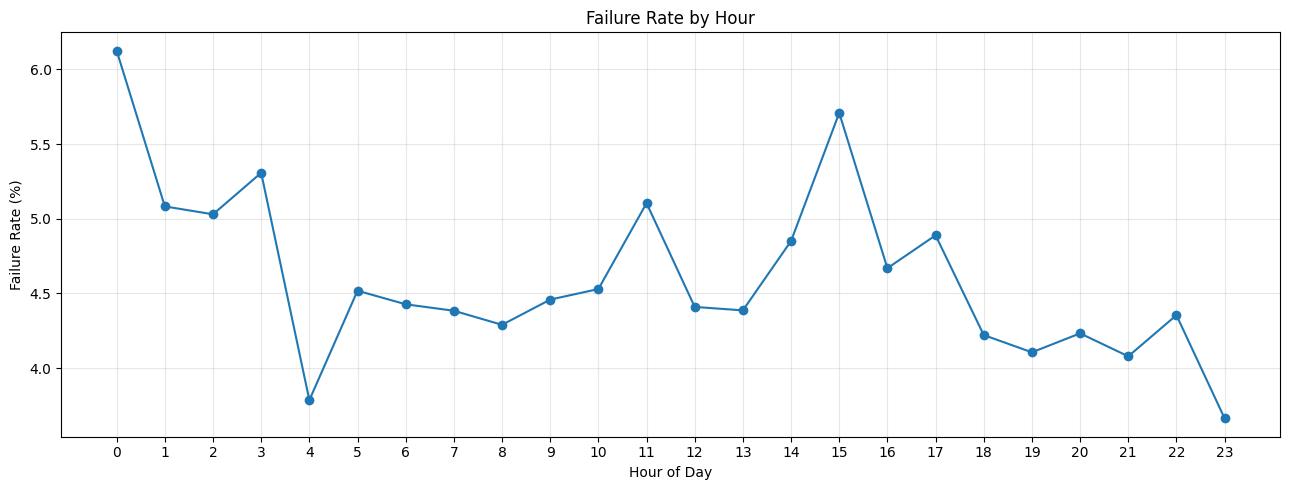

In [15]:
# ============================================================
# 16. HOURLY FAILURE RATE CHART
# ============================================================

plt.figure(figsize=(13, 5))

plt.plot(
    hourly["hour"],
    hourly["failure_rate_pct"],
    marker="o"
)

plt.title("Failure Rate by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Failure Rate (%)")
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# 17. VEHICLE CLASS analysis
# ============================================================

print("=" * 70)
print("VEHICLE CLASS / PACK TYPE ANALYSIS")
print("=" * 70)

vehicle_temp = swap_events.copy()
battery_temp = batteries.copy()

# ------------------------------------------------------------
# Normalize event type
# ------------------------------------------------------------
vehicle_temp["event_type_clean"] = (
    vehicle_temp["event_type"]
    .astype("string")
    .str.strip()
    .str.lower()
)

# ------------------------------------------------------------
# Check battery_out_id
# ------------------------------------------------------------
if "battery_out_id" not in vehicle_temp.columns:

    print("❌ battery_out_id column not found.")
    vehicle_analysis = pd.DataFrame()

else:

    # --------------------------------------------------------
    # Clean battery IDs
    # --------------------------------------------------------
    vehicle_temp["_battery_key"] = (
        vehicle_temp["battery_out_id"]
        .astype("string")
        .str.strip()
    )

    battery_temp["_battery_key"] = (
        battery_temp["battery_id"]
        .astype("string")
        .str.strip()
    )

    # --------------------------------------------------------
    # Find pack_type column
    # --------------------------------------------------------
    if "pack_type" not in battery_temp.columns:

        print("❌ pack_type column not found in batteries.")
        vehicle_analysis = pd.DataFrame()

    else:

        # ----------------------------------------------------
        # Create battery → pack type mapping
        # ----------------------------------------------------
        battery_map = (
            battery_temp[
                ["_battery_key", "pack_type"]
            ]
            .drop_duplicates("_battery_key")
        )

        # ----------------------------------------------------
        # Merge pack type into swap events
        # ----------------------------------------------------
        vehicle_temp = vehicle_temp.merge(
            battery_map,
            on="_battery_key",
            how="left"
        )

        # ----------------------------------------------------
        # Remove missing pack types
        # ----------------------------------------------------
        vehicle_temp["pack_type"] = (
            vehicle_temp["pack_type"]
            .astype("string")
            .str.strip()
        )

        vehicle_temp = vehicle_temp[
            vehicle_temp["pack_type"].notna()
            & (vehicle_temp["pack_type"] != "")
        ].copy()

        # ----------------------------------------------------
        # Analysis
        # ----------------------------------------------------
        vehicle_analysis = (
            vehicle_temp
            .groupby("pack_type")
            .agg(
                total_attempts=(
                    "event_type_clean",
                    "count"
                ),

                completed_swaps=(
                    "event_type_clean",
                    lambda x: (
                        x == "swap_completed"
                    ).sum()
                )
            )
            .reset_index()
        )

        # ----------------------------------------------------
        # Rates
        # ----------------------------------------------------
        vehicle_analysis["completion_rate_pct"] = np.where(
            vehicle_analysis["total_attempts"] > 0,

            vehicle_analysis["completed_swaps"]
            / vehicle_analysis["total_attempts"] * 100,

            0
        )

        vehicle_analysis["failure_rate_pct"] = (
            100
            - vehicle_analysis["completion_rate_pct"]
        )

        # ----------------------------------------------------
        # Sort
        # ----------------------------------------------------
        vehicle_analysis = vehicle_analysis.sort_values(
            "total_attempts",
            ascending=False
        )

        print("\n✅ Vehicle class analysis completed.")
        print("\nPack types found:")

        display(vehicle_analysis)

VEHICLE CLASS / PACK TYPE ANALYSIS

✅ Vehicle class analysis completed.

Pack types found:


,pack_type,total_attempts,completed_swaps,completion_rate_pct,failure_rate_pct
0,2W_2.1kWh,127835,127835,100.0,0.0
1,3W_4.8kWh,16170,16170,100.0,0.0


In [17]:
# ============================================================
# 18. QUEUE / ABANDONED SWAP ANALYSIS
# ============================================================

print("=" * 70)
print("QUEUE / ABANDONED SWAP ANALYSIS")
print("=" * 70)

queue_temp = swap_events.copy()

queue_temp["event_type_clean"] = (
    queue_temp["event_type"]
    .astype("string")
    .str.strip()
    .str.lower()
)

queue_analysis = (
    queue_temp
    .groupby("event_type_clean")
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

display(queue_analysis)

QUEUE / ABANDONED SWAP ANALYSIS


,event_type_clean,count
4,swap_completed,144005
2,failed_no_charged_battery,3670
0,abandoned_queue,1920
1,cancelled_by_rider,616
3,failed_system_error,446


In [18]:
# ============================================================
# 19. BATTERY ANALYSIS
# ============================================================

print("=" * 70)
print("BATTERY ANALYSIS")
print("=" * 70)

battery_temp = batteries.copy()

print("Battery dataset shape:", battery_temp.shape)

display(battery_temp.head())

# Numeric conversion where available
for col in [
    "soh_pct",
    "charge_cycles",
    "delivered_range_km"
]:
    if col in battery_temp.columns:
        battery_temp[col] = pd.to_numeric(
            battery_temp[col],
            errors="coerce"
        )

display(
    battery_temp.describe(include="all").T
)

BATTERY ANALYSIS
Battery dataset shape: (6500, 13)


,battery_id,pack_type,supplier,manufacturing_lot,manufacture_date,commission_date,rated_capacity_kwh,purchase_cost_inr,initial_soh_pct,bms_firmware,retired_date,retirement_reason,current_soh_pct
0,BAT-2W-100000,2W_2.1kWh,Cellora,CE-2503,2025-01-30,2025-03-19,2.1,31018,99.9,BMS-4.1,NaN,NaN,79.5
1,BAT-2W-100001,2W_2.1kWh,Cellora,CE-2403,2024-02-27,2024-03-30,2.1,34111,99.2,BMS-4.2,NaN,NaN,79.5
2,BAT-3W-100002,3W_4.8kWh,Cellora,CE-2305,2023-04-15,2023-05-11,4.8,66521,99.5,BMS-4.1,NaN,NaN,87.0
3,BAT-2W-100003,2W_2.1kWh,Kyron,KY-2409,2024-09-28,2024-10-09,2.1,32753,99.5,BMS-4.1,2025-06-15,end_of_life,58.1
4,BAT-2W-100004,2W_2.1kWh,Kyron,KY-2407,2024-11-06,2024-11-21,2.1,31734,99.5,BMS-4.2,2025-06-15,end_of_life,60.6


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
battery_id,6500,6500,BAT-2W-106499,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pack_type,6500,2,2W_2.1kWh,5518,NaN,NaN,NaN,NaN,NaN,NaN,NaN
supplier,6500,3,Cellora,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
manufacturing_lot,6500,55,KY-2408,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
manufacture_date,6500,862,2024-10-10,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
commission_date,6500,826,2024-09-13,36,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rated_capacity_kwh,6500.0,NaN,NaN,NaN,2.507908,0.967009,2.1,2.1,2.1,2.1,4.8
purchase_cost_inr,6500.0,NaN,NaN,NaN,37414.073538,12951.496627,27473.0,31339.5,32250.0,33397.25,75037.0
initial_soh_pct,6500.0,NaN,NaN,NaN,99.191292,0.39747,97.8,98.9,99.2,99.5,100.0
bms_firmware,6500,3,BMS-4.1,2197,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
# ============================================================
# 20. SUPPORT TICKET ANALYSIS
# ============================================================

print("=" * 70)
print("SUPPORT TICKET ANALYSIS")
print("=" * 70)

ticket_temp = support_tickets.copy()

print("Total support tickets:", len(ticket_temp))

if "category" in ticket_temp.columns:

    ticket_category = (
        ticket_temp["category"]
        .astype("string")
        .str.strip()
        .value_counts()
        .reset_index()
    )

    ticket_category.columns = [
        "category",
        "ticket_count"
    ]

    display(ticket_category)

else:
    print("⚠️ category column not found.")

SUPPORT TICKET ANALYSIS
Total support tickets: 44000


,category,ticket_count
0,no_battery_available,11647
1,other,9484
2,low_range,6636
3,app_issue,5787
4,long_queue,5731
5,billing_dispute,4715


In [20]:
# ============================================================
# 21. FINAL PROJECT SUMMARY
# ============================================================

print("=" * 70)
print("FINAL PROJECT SUMMARY")
print("=" * 70)

print("\nMain datasets:")

print(
    f"Swap events       : {len(swap_events):,} rows"
)

print(
    f"Stations           : {len(stations):,} rows"
)

print(
    f"Batteries          : {len(batteries):,} rows"
)

print(
    f"Riders             : {len(riders):,} rows"
)

print(
    f"Support tickets    : {len(support_tickets):,} rows"
)

print(
    f"Fleet partners     : {len(fleet_partners):,} rows"
)

print(
    f"City daily context : {len(city_daily_context):,} rows"
)

# ------------------------------------------------------------
# Hourly status dataset — safe check
# ------------------------------------------------------------

if "station_hourly_status" in globals():

    print(
        f"Hourly status      : "
        f"{len(station_hourly_status):,} rows"
    )

else:

    print(
        "Hourly status      : Not loaded in notebook"
    )

print("\n" + "=" * 70)
print("PROJECT ANALYSIS STATUS")
print("=" * 70)

# Check analysis outputs
analysis_objects = {
    "Monthly performance": "monthly",
    "Station performance": "station_performance",
    "City performance": "city_performance",
    "Hourly performance": "hourly",
    "Vehicle/pack analysis": "vehicle_analysis",
    "Support ticket analysis": "ticket_category"
}

for name, variable in analysis_objects.items():

    if variable in globals():

        obj = globals()[variable]

        if isinstance(obj, pd.DataFrame) and not obj.empty:
            print(f"✅ {name}")
        else:
            print(f"⚠️ {name} — empty")

    else:
        print(f"⚠️ {name} — not created")

print("\n✅ FINAL SUMMARY COMPLETED")

FINAL PROJECT SUMMARY

Main datasets:
Swap events       : 150,657 rows
Stations           : 152 rows
Batteries          : 6,500 rows
Riders             : 20,000 rows
Support tickets    : 44,000 rows
Fleet partners     : 12 rows
City daily context : 3,282 rows
Hourly status      : Not loaded in notebook

PROJECT ANALYSIS STATUS
✅ Monthly performance
✅ Station performance
✅ City performance
✅ Hourly performance
✅ Vehicle/pack analysis
✅ Support ticket analysis

✅ FINAL SUMMARY COMPLETED


In [21]:
# ============================================================
# CELL 22 — BATTERY & SUPPLIER ANALYSIS
# ============================================================

print("=" * 70)
print("BATTERY & SUPPLIER ANALYSIS")
print("=" * 70)

if "batteries" not in globals():
    print("⚠️ batteries dataframe not loaded. Skipping.")
else:
    b = batteries.copy()
    b.columns = [str(c).strip().lower() for c in b.columns]

    # Convert only the fields that exist and are numeric in nature
    for col in ["soh_pct", "charge_cycles", "delivered_range_km"]:
        if col in b.columns:
            b[col] = pd.to_numeric(b[col], errors="coerce")

    # Supplier-level comparison
    if "supplier" in b.columns:
        agg = {"battery_count": ("battery_id", "count") if "battery_id" in b.columns else ("supplier", "size")}
        if "soh_pct" in b.columns:
            agg["avg_soh_pct"] = ("soh_pct", "mean")
        if "charge_cycles" in b.columns:
            agg["avg_charge_cycles"] = ("charge_cycles", "mean")
        if "delivered_range_km" in b.columns:
            agg["avg_delivered_range_km"] = ("delivered_range_km", "mean")

        supplier_analysis = b.groupby("supplier", dropna=False).agg(**agg).reset_index()
        print("\nSupplier Performance:")
        display(supplier_analysis.round(2))
    else:
        print("No supplier column available.")

    # Pack-type comparison
    if "pack_type" in b.columns:
        agg = {"battery_count": ("battery_id", "count") if "battery_id" in b.columns else ("pack_type", "size")}
        if "soh_pct" in b.columns:
            agg["avg_soh_pct"] = ("soh_pct", "mean")
        if "charge_cycles" in b.columns:
            agg["avg_charge_cycles"] = ("charge_cycles", "mean")
        if "delivered_range_km" in b.columns:
            agg["avg_range_km"] = ("delivered_range_km", "mean")

        pack_analysis = b.groupby("pack_type", dropna=False).agg(**agg).reset_index()
        print("\nPack Type Performance:")
        display(pack_analysis.round(2))
    else:
        print("No pack_type column available.")

    # Overall battery health snapshot
    health_metrics = []
    if "soh_pct" in b.columns:
        health_metrics.append(["Average SOH (%)", b["soh_pct"].mean()])
    if "charge_cycles" in b.columns:
        health_metrics.append(["Average Charge Cycles", b["charge_cycles"].mean()])
    if "delivered_range_km" in b.columns:
        health_metrics.append(["Average Delivered Range (km)", b["delivered_range_km"].mean()])
    if health_metrics:
        print("\nOverall Battery Health:")
        display(pd.DataFrame(health_metrics, columns=["Metric", "Value"]).round(2))

    # Relationship between usage and battery health
    if "soh_pct" in b.columns and "charge_cycles" in b.columns:
        plt.figure(figsize=(10, 5))
        plt.scatter(b["charge_cycles"], b["soh_pct"], alpha=0.25, s=10)
        plt.xlabel("Charge Cycles")
        plt.ylabel("State of Health (%)")
        plt.title("Battery Health vs Charge Cycles")
        plt.grid(alpha=0.2)
        plt.show()


BATTERY & SUPPLIER ANALYSIS

Supplier Performance:


,supplier,battery_count
0,Amptek,1307
1,Cellora,3555
2,Kyron,1638



Pack Type Performance:


,pack_type,battery_count
0,2W_2.1kWh,5518
1,3W_4.8kWh,982


RIDER RETENTION ANALYSIS

30-Day Rider Retention:


,status,riders,percentage
0,Retained,3476,79.11
1,Not Retained,918,20.89



Rider Activity Distribution:


,completed_swaps
count,4394.00
mean,32.77
std,12.78
min,1.00
25%,27.00
50%,34.00
75%,40.00
max,76.00



Retention by vehicle_class:


,vehicle_class,riders,retained_30d,retention_rate_pct
0,2W,3754,2973,79.20
1,3W,640,503,78.59


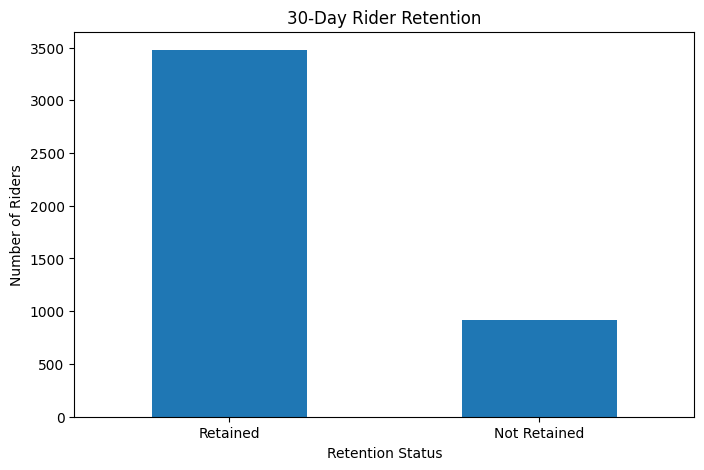

In [22]:
# ============================================================
# CELL 24 — RIDER RETENTION ANALYSIS
# ============================================================

print("=" * 70)
print("RIDER RETENTION ANALYSIS")
print("=" * 70)

if "swap_events" not in globals():
    print("⚠️ swap_events dataframe not available.")

else:

    rr = swap_events.copy()

    rr["event_ts"] = pd.to_datetime(
        rr["event_ts"],
        errors="coerce",
        format="mixed"
    )

    rr = rr.dropna(subset=["event_ts"])

    # Valid completed swaps
    if "event_type" in rr.columns:
        completed_rr = rr[
            rr["event_type"].astype(str).str.lower() == "swap_completed"
        ].copy()
    else:
        completed_rr = rr.copy()

    # --------------------------------------------------------
    # Rider first and last completed swap
    # --------------------------------------------------------

    rider_activity = (
        completed_rr.groupby("rider_id")
        .agg(
            first_swap=("event_ts", "min"),
            last_swap=("event_ts", "max"),
            completed_swaps=("event_ts", "count")
        )
        .reset_index()
    )

    # A rider is considered retained if they completed
    # another swap at least 30 days after first completed swap.
    rider_activity["retained_30d"] = (
        rider_activity["last_swap"] -
        rider_activity["first_swap"]
    ).dt.days >= 30

    rider_activity["retention_status"] = np.where(
        rider_activity["retained_30d"],
        "Retained",
        "Not Retained"
    )

    retention_summary = (
        rider_activity["retention_status"]
        .value_counts()
        .rename_axis("status")
        .reset_index(name="riders")
    )

    retention_summary["percentage"] = (
        retention_summary["riders"] /
        retention_summary["riders"].sum() * 100
    )

    print("\n30-Day Rider Retention:")
    display(retention_summary.round(2))

    # --------------------------------------------------------
    # Completed swaps per rider
    # --------------------------------------------------------

    print("\nRider Activity Distribution:")
    display(
        rider_activity["completed_swaps"]
        .describe()
        .to_frame("completed_swaps")
        .round(2)
    )

    # --------------------------------------------------------
    # Retention by rider segment if available
    # --------------------------------------------------------

    if "riders" in globals():

        r = riders.copy()
        r.columns = [str(c).strip().lower() for c in r.columns]

        if "rider_id" in r.columns:

            possible_segments = [
                "vehicle_class",
                "rider_type",
                "customer_type",
                "partner_id"
            ]

            segment_col = next(
                (c for c in possible_segments if c in r.columns),
                None
            )

            if segment_col:

                temp_ret = rider_activity.merge(
                    r[["rider_id", segment_col]].drop_duplicates("rider_id"),
                    on="rider_id",
                    how="left"
                )

                segment_retention = (
                    temp_ret.groupby(segment_col, dropna=False)
                    .agg(
                        riders=("rider_id", "count"),
                        retained_30d=("retained_30d", "sum")
                    )
                    .reset_index()
                )

                segment_retention["retention_rate_pct"] = (
                    segment_retention["retained_30d"] /
                    segment_retention["riders"] * 100
                )

                print(f"\nRetention by {segment_col}:")
                display(segment_retention.round(2))

    # Chart
    plt.figure(figsize=(8, 5))
    rider_activity["retention_status"].value_counts().plot(
        kind="bar"
    )
    plt.title("30-Day Rider Retention")
    plt.xlabel("Retention Status")
    plt.ylabel("Number of Riders")
    plt.xticks(rotation=0)
    plt.show()

In [23]:
# ============================================================
# CELL 23 — PRICING & FLEET ECONOMICS
# ============================================================

print("=" * 70)
print("PRICING & FLEET ECONOMICS")
print("=" * 70)

if "swap_events" not in globals():
    print("⚠️ swap_events dataframe not available.")
else:
    pe = swap_events.copy()
    pe.columns = [str(c).strip().lower() for c in pe.columns]

    if "event_type" in pe.columns:
        pe = pe[pe["event_type"].astype(str).str.lower().str.strip().eq("swap_completed")].copy()

    for col in ["amount_charged_inr", "list_price_inr", "discount_inr"]:
        if col in pe.columns:
            pe[col] = pd.to_numeric(pe[col], errors="coerce")

    # Tariff performance
    if "tariff_code" in pe.columns and "amount_charged_inr" in pe.columns:
        tariff_analysis = (
            pe.groupby("tariff_code", dropna=False)
              .agg(
                  completed_swaps=("event_id", "count") if "event_id" in pe.columns else ("tariff_code", "size"),
                  revenue=("amount_charged_inr", "sum"),
                  avg_revenue_per_swap=("amount_charged_inr", "mean")
              )
              .reset_index()
        )
        print("\nTariff Performance:")
        display(tariff_analysis.round(2))

    # Fleet vs independent riders
    if "riders" in globals():
        r = riders.copy()
        r.columns = [str(c).strip().lower() for c in r.columns]
        if "rider_id" in r.columns and "partner_id" in r.columns and "amount_charged_inr" in pe.columns:
            fleet_map = r[["rider_id", "partner_id"]].drop_duplicates("rider_id")
            pe_fleet = pe.merge(fleet_map, on="rider_id", how="left")
            pe_fleet["rider_segment"] = np.where(
                pe_fleet["partner_id"].notna() & pe_fleet["partner_id"].astype(str).str.strip().ne(""),
                "Fleet",
                "Independent"
            )
            fleet_analysis = (
                pe_fleet.groupby("rider_segment")
                .agg(
                    completed_swaps=("event_id", "count") if "event_id" in pe_fleet.columns else ("rider_id", "size"),
                    revenue=("amount_charged_inr", "sum"),
                    avg_revenue_per_swap=("amount_charged_inr", "mean")
                )
                .reset_index()
            )
            print("\nFleet vs Independent Economics:")
            display(fleet_analysis.round(2))
    else:
        print("Rider master table not loaded; fleet segmentation skipped.")


PRICING & FLEET ECONOMICS

Tariff Performance:


,tariff_code,completed_swaps,revenue,avg_revenue_per_swap
0,PARTNER,96826,5682301.4,58.69
1,STD,47179,2945350.0,62.43



Fleet vs Independent Economics:


,rider_segment,completed_swaps,revenue,avg_revenue_per_swap
0,Fleet,96826,5682301.4,58.69
1,Independent,47179,2945350.0,62.43


In [24]:
# ============================================================
# CELL 25 — CONTRIBUTION MARGIN ANALYSIS
# ============================================================

print("=" * 70)
print("CONTRIBUTION MARGIN ANALYSIS")
print("=" * 70)

if "swap_events" not in globals():
    print("⚠️ swap_events dataframe not available.")

else:

    cm = swap_events.copy()

    cm["event_ts"] = pd.to_datetime(
        cm["event_ts"],
        errors="coerce",
        format="mixed"
    )

    cm = cm.dropna(subset=["event_ts"])

    # Completed swaps only
    if "event_type" in cm.columns:
        cm = cm[
            cm["event_type"].astype(str).str.lower() == "swap_completed"
        ].copy()

    # Numeric conversion
    for col in [
        "amount_charged_inr",
        "list_price_inr",
        "discount_inr",
        "energy_to_recharge_kwh"
    ]:
        if col in cm.columns:
            cm[col] = pd.to_numeric(cm[col], errors="coerce")

    # Detect possible explicit cost columns
    cost_candidates = [
        "variable_cost_inr",
        "energy_cost_inr",
        "cost_inr",
        "contribution_cost_inr",
        "charging_cost_inr"
    ]

    available_cost = [
        c for c in cost_candidates
        if c in cm.columns
    ]

    print("Detected cost columns:", available_cost)

    if "amount_charged_inr" in cm.columns and available_cost:

        cost_col = available_cost[0]

        cm["contribution_margin_inr"] = (
            cm["amount_charged_inr"] -
            pd.to_numeric(cm[cost_col], errors="coerce")
        )

        summary = pd.DataFrame({
            "Metric": [
                "Completed Swaps",
                "Revenue",
                "Total Contribution Margin",
                "Contribution Margin / Swap",
                "Contribution Margin %"
            ],
            "Value": [
                len(cm),
                cm["amount_charged_inr"].sum(),
                cm["contribution_margin_inr"].sum(),
                cm["contribution_margin_inr"].mean(),
                (
                    cm["contribution_margin_inr"].sum() /
                    cm["amount_charged_inr"].sum() * 100
                )
            ]
        })

        display(summary.round(2))

        # Monthly margin
        cm["month"] = (
            cm["event_ts"]
            .dt.to_period("M")
            .dt.to_timestamp()
        )

        monthly_margin = (
            cm.groupby("month")
            .agg(
                completed_swaps=("event_id", "count"),
                revenue=("amount_charged_inr", "sum"),
                contribution_margin=("contribution_margin_inr", "sum")
            )
            .reset_index()
        )

        monthly_margin["margin_per_swap"] = (
            monthly_margin["contribution_margin"] /
            monthly_margin["completed_swaps"]
        )

        print("\nMonthly Contribution Margin:")
        display(monthly_margin.round(2))

        plt.figure(figsize=(12, 5))
        plt.plot(
            monthly_margin["month"],
            monthly_margin["margin_per_swap"],
            marker="o"
        )
        plt.title("Monthly Contribution Margin per Completed Swap")
        plt.xlabel("Month")
        plt.ylabel("Contribution Margin per Swap (INR)")
        plt.xticks(rotation=45)
        plt.grid(alpha=0.2)
        plt.show()

    else:

        print(
            "\n⚠️ No explicit variable-cost column was detected."
        )
        print(
            "Contribution margin cannot be calculated reliably "
            "from the currently loaded swap_events columns."
        )
        print(
            "Revenue can still be used, but do NOT label revenue "
            "as contribution margin."
        )

        if "amount_charged_inr" in cm.columns:

            print(
                "\nRevenue summary available instead:"
            )

            display(
                pd.DataFrame({
                    "Metric": [
                        "Completed Swaps",
                        "Total Revenue",
                        "Average Revenue per Swap"
                    ],
                    "Value": [
                        len(cm),
                        cm["amount_charged_inr"].sum(),
                        cm["amount_charged_inr"].mean()
                    ]
                }).round(2)
            )

CONTRIBUTION MARGIN ANALYSIS
Detected cost columns: []

⚠️ No explicit variable-cost column was detected.
Contribution margin cannot be calculated reliably from the currently loaded swap_events columns.
Revenue can still be used, but do NOT label revenue as contribution margin.

Revenue summary available instead:


,Metric,Value
0,Completed Swaps,144005.00
1,Total Revenue,8627651.40
2,Average Revenue per Swap,59.91


In [25]:
# ============================================================
# CELL 26 — FINAL KEY FINDINGS
# ============================================================

print("=" * 80)
print("VOLTRELAY ENERGY — FINAL ANALYTICAL SUMMARY")
print("=" * 80)

# ------------------------------------------------------------
# NETWORK
# ------------------------------------------------------------

if "swap_events" in globals():

    final_df = swap_events.copy()

    total_attempts = len(final_df)

    if "event_type" in final_df.columns:

        event_clean = (
            final_df["event_type"]
            .astype(str)
            .str.lower()
            .str.strip()
        )

        completed = (event_clean == "swap_completed").sum()

        failure_rate = (
            (total_attempts - completed) /
            total_attempts * 100
            if total_attempts > 0 else 0
        )

        completion_rate = (
            completed /
            total_attempts * 100
            if total_attempts > 0 else 0
        )

        print(f"\nTotal analysed attempts : {total_attempts:,}")
        print(f"Completed swaps         : {completed:,}")
        print(f"Completion rate         : {completion_rate:.2f}%")
        print(f"Non-completion rate     : {failure_rate:.2f}%")

        print("\nEvent Type Breakdown:")

        event_summary = (
            event_clean
            .value_counts()
            .rename_axis("event_type")
            .reset_index(name="count")
        )

        event_summary["percentage"] = (
            event_summary["count"] /
            event_summary["count"].sum() * 100
        )

        display(event_summary.round(2))

# ------------------------------------------------------------
# REVENUE
# ------------------------------------------------------------

if "swap_events" in globals():

    revenue_df = swap_events.copy()

    if "event_type" in revenue_df.columns:
        revenue_df = revenue_df[
            revenue_df["event_type"]
            .astype(str)
            .str.lower()
            .str.strip()
            .eq("swap_completed")
        ].copy()

    if "amount_charged_inr" in revenue_df.columns:

        revenue_df["amount_charged_inr"] = pd.to_numeric(
            revenue_df["amount_charged_inr"],
            errors="coerce"
        )

        print("\nRevenue:")
        print(
            f"Total Revenue        : "
            f"₹{revenue_df['amount_charged_inr'].sum():,.2f}"
        )

        print(
            f"Average Revenue/Swap : "
            f"₹{revenue_df['amount_charged_inr'].mean():,.2f}"
        )

# ------------------------------------------------------------
# RETENTION
# ------------------------------------------------------------

if "rider_activity" in globals():

    retained = rider_activity["retained_30d"].sum()
    total_riders = len(rider_activity)

    retention_rate = (
        retained / total_riders * 100
        if total_riders > 0 else 0
    )

    print("\nRider Retention:")
    print(f"Riders analysed       : {total_riders:,}")
    print(f"30-day retained       : {retained:,}")
    print(f"30-day retention rate : {retention_rate:.2f}%")

# ------------------------------------------------------------
# BATTERY
# ------------------------------------------------------------

if "batteries" in globals():

    print("\nBattery Dataset:")
    print(f"Battery records       : {len(batteries):,}")

    if "supplier" in batteries.columns:

        print(
            f"Suppliers analysed    : "
            f"{batteries['supplier'].nunique(dropna=True)}"
        )

    if "pack_type" in batteries.columns:

        print(
            f"Pack types analysed   : "
            f"{batteries['pack_type'].nunique(dropna=True)}"
        )

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE — FINAL NOTEBOOK")
print("=" * 80)
print(
    "Use the outputs above as evidence for the final report/video. "
    "Contribution margin is reported only if an explicit cost field exists. "
    "Do not add unsupported causal claims."
)

VOLTRELAY ENERGY — FINAL ANALYTICAL SUMMARY

Total analysed attempts : 150,657
Completed swaps         : 144,005
Completion rate         : 95.58%
Non-completion rate     : 4.42%

Event Type Breakdown:


,event_type,count,percentage
0,swap_completed,144005,95.58
1,failed_no_charged_battery,3670,2.44
2,abandoned_queue,1920,1.27
3,cancelled_by_rider,616,0.41
4,failed_system_error,446,0.30



Revenue:
Total Revenue        : ₹8,627,651.40
Average Revenue/Swap : ₹59.91

Rider Retention:
Riders analysed       : 4,394
30-day retained       : 3,476
30-day retention rate : 79.11%

Battery Dataset:
Battery records       : 6,500
Suppliers analysed    : 3
Pack types analysed   : 2

ANALYSIS COMPLETE — FINAL NOTEBOOK
Use the outputs above as evidence for the final report/video. Contribution margin is reported only if an explicit cost field exists. Do not add unsupported causal claims.


## Submission Checklist

- Run **Runtime → Run all** before submission.
- Confirm every code cell completes without errors.
- Use the outputs from this notebook as evidence in the final report and 3-minute video.
- Do not describe revenue as contribution margin unless an explicit cost field is available.
- Do not make causal claims from observational patterns.
